In [15]:
# Khai báo thư viện và đọc dữ liệu đầu vào
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import scipy.stats as stats

# 1. Đọc dữ liệu gốc
df_raw = pd.read_csv('../Data/Risk_data_FE.csv', index_col=0)
target_col = 'loan_status'

# [ĐIỂM KHÁC BIỆT BỔ SUNG]: Kiểm tra phân bổ nhãn để đảm bảo 0 = Tốt, 1 = Xấu
print("=== PHÂN BỔ NHÃN TRONG DATASET GỐC ===")
print(df_raw[target_col].value_counts())
print("-" * 60)

# Loại bỏ các biến dính lỗi hệ thống đã phân tích ở các bước trước
features_to_drop = ['loan_grade_numeric', 'loan_percent_income']
features_to_drop = [col for col in features_to_drop if col in df_raw.columns]
df_filtered = df_raw.drop(columns=features_to_drop).copy()

=== PHÂN BỔ NHÃN TRONG DATASET GỐC ===
loan_status
0    24854
1     6825
Name: count, dtype: int64
------------------------------------------------------------


In [16]:
# Hàm tính WOE và IV, sửa tận gốc bộ đếm nhãn
def calculate_woe_iv_clean(df, target, num_bins=6):
    iv_records = []
    woe_maps = {}
    
    features = [col for col in df.columns if col != target]
    
    # Tính tổng số ca Bad (1) và Good (0) của toàn bộ hệ thống
    total_bads = df[target].sum()
    total_goods = df[target].count() - total_bads
    
    for feat in features:
        try:
            df_temp = df[[feat, target]].copy().dropna()
            
            if np.issubdtype(df_temp[feat].dtype, np.number):
                df_temp['bin'] = pd.qcut(df_temp[feat], q=num_bins, duplicates='drop')
            else:
                df_temp['bin'] = df_temp[feat]
                
            # [ĐIỂM KHÁC BIỆT CỐT LÕI]: Ép điều kiện đếm chuẩn xác nhãn nhị phân
            grouped = df_temp.groupby('bin', observed=False).agg(
                Good=(target, lambda x: (x == 0).sum()),  # Bản cũ có thể dùng phép trừ sai lệch
                Bad=(target, lambda x: (x == 1).sum()),   # Bản cũ tính gộp chung
                Total=(target, 'count')
            ).reset_index()
            
            grouped['%_Good'] = grouped['Good'] / total_goods
            grouped['%_Bad'] = grouped['Bad'] / total_bads
            
            grouped['%_Good'] = grouped['%_Good'].replace(0, 0.0001)
            grouped['%_Bad'] = grouped['%_Bad'].replace(0, 0.0001)
            
            # WOE = ln(%_Good / %_Bad) -> Nhóm tốt ra điểm Dương (+), Nhóm xấu ra điểm Âm (-)
            grouped['WOE'] = np.log(grouped['%_Good'] / grouped['%_Bad'])
            grouped['IV_bin'] = (grouped['%_Good'] - grouped['%_Bad']) * grouped['WOE']
            
            total_iv = grouped['IV_bin'].sum()
            grouped['bin'] = grouped['bin'].astype(str)
            
            woe_maps[feat] = grouped
            
            if total_iv < 0.02: predictive_power = "1. Quá yếu (Loại bỏ)"
            elif total_iv < 0.1: predictive_power = "2. Yếu (Cân nhắc)"
            elif total_iv < 0.3: predictive_power = "3. Trung bình (Tốt)"
            elif total_iv < 0.5: predictive_power = "4. Mạnh (Cốt lõi)"
            else: predictive_power = "5. Quá mạnh (Cần kiểm tra kỹ)"
                
            iv_records.append({
                'Feature': feat,
                'IV_Value': round(total_iv, 4),
                'Predictive_Power': predictive_power
            })
        except Exception as e:
            continue
            
    df_iv = pd.DataFrame(iv_records).sort_values(by='IV_Value', ascending=False).reset_index(drop=True)
    return df_iv, woe_maps

# Chạy hàm tính toán mới
df_iv_new, woe_maps_new = calculate_woe_iv_clean(df_filtered, target_col, num_bins=6)

In [17]:
# Chuyển đổi dữ liệu sang ma trận điểm WOE
# Chọn các biến chiến lược đạt chuẩn IV
selected_features = df_iv_new[(df_iv_new['IV_Value'] >= 0.1) & (df_iv_new['IV_Value'] < 0.6)]['Feature'].tolist()

print("Các biến chiến lược được chọn đưa vào mô hình:", selected_features)
#Tạo ra một dataframe mới hoàn toàn để chứa điểm WOE
df_working = df_filtered.dropna(subset=[target_col] + selected_features).copy()
df_model_woe = pd.DataFrame()
df_model_woe[target_col] = df_working[target_col]

#Ánh xạ giá trị thô sang điểm WOE tương ứng
for feat in selected_features:
    if np.issubdtype(df_working[feat].dtype, np.number):
        df_working['bin_temp'] = pd.qcut(df_working[feat], q=6, duplicates='drop').astype(str)
    else:
        df_working['bin_temp'] = df_working[feat].astype(str)
        
    mapping_dict = dict(zip(woe_maps_new[feat]['bin'], woe_maps_new[feat]['WOE']))
    df_model_woe[f'{feat}_WOE'] = df_working['bin_temp'].map(mapping_dict)

df_model_woe = df_model_woe.fillna(0)
print("\nKích thước ma trận dữ liệu WOE thực chiến:", df_model_woe.shape)
print(df_model_woe.head())

Các biến chiến lược được chọn đưa vào mô hình: ['debt_to_income_ratio', 'person_income', 'installment_income_ratio', 'other_debt', 'cb_person_default_on_file', 'risk_interaction']

Kích thước ma trận dữ liệu WOE thực chiến: (31679, 7)
   loan_status  debt_to_income_ratio_WOE  person_income_WOE  \
1            0                  0.626061          -1.051658   
2            1                 -1.262121          -1.051658   
3            1                 -1.262121           0.334618   
4            1                 -1.262121           0.075868   
5            1                 -1.262121          -1.051658   

   installment_income_ratio_WOE  other_debt_WOE  \
1                      0.424459       -0.749958   
2                     -0.968562       -0.749958   
3                     -0.968562       -0.063251   
4                     -0.968562        0.351498   
5                     -0.325427       -0.749958   

   cb_person_default_on_file_WOE  risk_interaction_WOE  
1                     

In [18]:
# Kiểm tra lại VIF và huấn luyện mô hình Logistic mới

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_woe = df_model_woe.drop(columns=[target_col])
y_woe = df_model_woe[target_col]

# 1. Kiểm tra hệ số VIF mới trên dữ liệu đã biến đổi WOE
vif_data = pd.DataFrame()
vif_data["Feature"] = X_woe.columns
vif_data["VIF"] = [variance_inflation_factor(X_woe.values, i) for i in range(X_woe.shape[1])]
print("=== HỆ SỐ VIF SẠCH SẼ TRÊN NỀN BIẾN ĐỔI WOE ===")
print(vif_data)
print("-" * 60)

# 2. Tách tập Train/Test (Tỷ lệ 70/30)
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_woe, y_woe, test_size=0.3, random_state=42, stratify=y_woe)

# 3. Huấn luyện mô hình
log_model_woe_final = LogisticRegression(random_state=42)
log_model_woe_final.fit(X_train_w, y_train_w)

print(f"Hệ số chặn (Intercept Beta_0): {log_model_woe_final.intercept_[0]:.4f}")
print("\n=== TRỌNG SỐ (BETA COEFFICIENT) CỦA CÁC BIẾN ===")
for feat, coef in zip(X_woe.columns, log_model_woe_final.coef_[0]):
    print(f"[*] {feat}: {coef:.4f}")

=== HỆ SỐ VIF SẠCH SẼ TRÊN NỀN BIẾN ĐỔI WOE ===
                         Feature       VIF
0       debt_to_income_ratio_WOE  2.259154
1              person_income_WOE  2.467682
2   installment_income_ratio_WOE  1.751381
3                 other_debt_WOE  2.450601
4  cb_person_default_on_file_WOE  1.003918
5           risk_interaction_WOE  1.346454
------------------------------------------------------------
Hệ số chặn (Intercept Beta_0): -1.2983

=== TRỌNG SỐ (BETA COEFFICIENT) CỦA CÁC BIẾN ===
[*] debt_to_income_ratio_WOE: -0.9030
[*] person_income_WOE: -0.3041
[*] installment_income_ratio_WOE: -0.1735
[*] other_debt_WOE: -0.9639
[*] cb_person_default_on_file_WOE: -1.0980
[*] risk_interaction_WOE: -0.2713


In [19]:
# Huấn luyện logistic và kiểm tra overfitting
X_woe = df_model_woe.drop(columns=[target_col])
y_woe = df_model_woe[target_col]

# Chia tách tập Train/Test dữ liệu sạch
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_woe, y_woe, test_size=0.3, random_state=42, stratify=y_woe)

# Train mô hình
log_model_woe_final = LogisticRegression(random_state=42)
log_model_woe_final.fit(X_train_w, y_train_w)

# Đối chiếu AUC chống học vẹt (Overfitting Check)
y_pred_prob_train = log_model_woe_final.predict_proba(X_train_w)[:, 1]
y_pred_prob_test = log_model_woe_final.predict_proba(X_test_w)[:, 1]

print(f"[*] Train AUC: {roc_auc_score(y_train_w, y_pred_prob_train):.4f}")
print(f"[*] Test AUC : {roc_auc_score(y_test_w, y_pred_prob_test):.4f}")

[*] Train AUC: 0.7761
[*] Test AUC : 0.7763


In [20]:
# Đánh giá hiệu năng thực tế của mô hình 
y_pred_prob_w = log_model_woe_final.predict_proba(X_test_w)[:, 1]

# Tính toán AUC và Gini
auc_w = roc_auc_score(y_test_w, y_pred_prob_w)
gini_w = 2 * auc_w - 1

# Tính toán chỉ số tách biệt rủi ro KS
data_ks_w = pd.DataFrame({'real': y_test_w, 'prob': y_pred_prob_w})
bads_w = data_ks_w[data_ks_w['real'] == 1]['prob']
goods_w = data_ks_w[data_ks_w['real'] == 0]['prob']
ks_stat_w, _ = stats.ks_2samp(bads_w, goods_w)

# Tìm điểm chặn Cutoff tối ưu bằng Youden J-Statistic
fpr_w, tpr_w, thresholds_w = roc_curve(y_test_w, y_pred_prob_w)
optimal_idx_w = np.argmax(tpr_w - fpr_w)
optimal_cutoff_w = thresholds_w[optimal_idx_w]

print("======================================================")
print(" CHỈ SỐ HIỆU NĂNG MÔ HÌNH THỰC CHIẾN (SAU KHI SỬA)")
print("======================================================")
print(f"[*] AUC Score      : {auc_w:.4f}")
print(f"[*] Gini Score     : {gini_w:.4f}")
print(f"[*] KS Statistic   : {ks_stat_w:.4f}")
print(f"[👉] NGƯỠNG CUTOFF PD TỐI ƯU ĐỀ XUẤT: {optimal_cutoff_w:.4f}")
print("======================================================")

 CHỈ SỐ HIỆU NĂNG MÔ HÌNH THỰC CHIẾN (SAU KHI SỬA)
[*] AUC Score      : 0.7763
[*] Gini Score     : 0.5525
[*] KS Statistic   : 0.4225
[👉] NGƯỠNG CUTOFF PD TỐI ƯU ĐỀ XUẤT: 0.2269


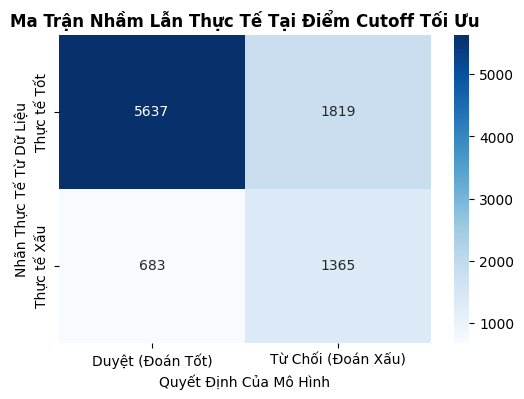


=== BÁO CÁO CHI TIẾT HIỆU NĂNG PHÂN LOẠI ===
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      7456
           1       0.43      0.67      0.52      2048

    accuracy                           0.74      9504
   macro avg       0.66      0.71      0.67      9504
weighted avg       0.79      0.74      0.75      9504



In [21]:
# Áp dụng cutoff vào thực tế và In ma trận nhầm lẫn (Confusion Matrix)
from sklearn.metrics import confusion_matrix, classification_report

# 1. Chuyển đổi xác suất PD thành quyết định Nhị phân (0 hoặc 1) dựa trên Cutoff tối ưu vừa tìm được
y_pred_final = np.where(y_pred_prob_w >= optimal_cutoff_w, 1, 0)

# 2. Tạo ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_test_w, y_pred_final)

# Trực quan hóa ma trận nhầm lẫn dạng bảng đẹp mắt bằng Seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Duyệt (Đoán Tốt)', 'Từ Chối (Đoán Xấu)'],
            yticklabels=['Thực tế Tốt', 'Thực tế Xấu'])
plt.title('Ma Trận Nhầm Lẫn Thực Tế Tại Điểm Cutoff Tối Ưu', fontsize=12, fontweight='bold')
plt.ylabel('Nhãn Thực Tế Từ Dữ Liệu')
plt.xlabel('Quyết Định Của Mô Hình')
plt.show()

# 3. In báo cáo chi tiết Precision, Recall, F1-Score
print("\n=== BÁO CÁO CHI TIẾT HIỆU NĂNG PHÂN LOẠI ===")
print(classification_report(y_test_w, y_pred_final))

In [22]:
# Chốt chặn 1: Kiểm tra "chống học vẹt" (Overfitting check) - so sánh chỉ số AUC giữa tập train và test
# 1. Dự báo xác suất PD trên cả 2 tập Train và Test
y_pred_prob_train = log_model_woe_final.predict_proba(X_train_w)[:, 1]
y_pred_prob_test = log_model_woe_final.predict_proba(X_test_w)[:, 1]

# 2. Tính chỉ số AUC cho cả 2 tập
auc_train = roc_auc_score(y_train_w, y_pred_prob_train)
auc_test = roc_auc_score(y_test_w, y_pred_prob_test)

print("======================================================")
print("     KIỂM TRA HIỆN TƯỢNG HỌC VẸT (OVERFITTING CHECK)")
print("======================================================")
print(f"[*] AUC trên tập Huấn luyện (Train AUC) : {auc_train:.4f}")
print(f"[*] AUC trên tập Kiểm thử (Test AUC)    : {auc_test:.4f}")
print(f"[*] Khoảng chênh lệch (Delta AUC)        : {abs(auc_train - auc_test):.4f}")
print("======================================================")

# Biện hộ kết quả tự động
if abs(auc_train - auc_test) <= 0.02:
    print("👉 Kết luận: Mô hình CỰC KỲ ỔN ĐỊNH. Không có dấu hiệu Overfitting!")
elif abs(auc_train - auc_test) <= 0.05:
    print("👉 Kết luận: Chênh lệch trong ngưỡng cho phép. Mô hình an toàn.")
else:
    print("👉 Cảnh báo: Chênh lệch lớn! Mô hình có dấu hiệu Overfitting (Học vẹt).")

     KIỂM TRA HIỆN TƯỢNG HỌC VẸT (OVERFITTING CHECK)
[*] AUC trên tập Huấn luyện (Train AUC) : 0.7761
[*] AUC trên tập Kiểm thử (Test AUC)    : 0.7763
[*] Khoảng chênh lệch (Delta AUC)        : 0.0002
👉 Kết luận: Mô hình CỰC KỲ ỔN ĐỊNH. Không có dấu hiệu Overfitting!


In [23]:
# Quy đổi hệ số thành bảng điểm credit scorecard chuẩn (Sửa công thức)
target_score = 600
target_odds = 50
pdo = 20

factor = pdo / np.log(2)
offset = target_score - (factor * np.log(target_odds))

intercept = log_model_woe_final.intercept_[0]
base_score = int((intercept * factor) + offset)

print("======================================================")
print("     BẢNG ĐIỂM CHẤM ĐIỂM TÍN DỤNG MỚI (CHUẨN NGHIỆP VỤ)")
print("======================================================")
print(f"[*] Điểm nền hệ thống (Base Score): {base_score} điểm\n")

for feat in selected_features:
    feat_index = X_woe.columns.get_loc(f"{feat}_WOE")
    beta_i = log_model_woe_final.coef_[0][feat_index]
    
    df_woe_feat = woe_maps_new[feat]
    print(f"--- BIẾN: {feat.upper()} ---")
    
    for idx, row in df_woe_feat.iterrows():
        # [ĐIỂM KHÁC BIỆT CỐT LÕI]: Thêm dấu TRỪ (-) phía trước công thức Scaling
        # Mục đích: Đảo ngược điểm để Biến an toàn (WOE dương) -> Ra điểm cộng Dương (+)
        bin_score = int(round(- (row['WOE'] * beta_i * factor)))
        print(f" Khoảng [{row['bin']}] ──► Nhận: {bin_score:+d} điểm")
    print("-" * 50)

     BẢNG ĐIỂM CHẤM ĐIỂM TÍN DỤNG MỚI (CHUẨN NGHIỆP VỤ)
[*] Điểm nền hệ thống (Base Score): 449 điểm

--- BIẾN: DEBT_TO_INCOME_RATIO ---
 Khoảng [(0.0635, 0.219]] ──► Nhận: +20 điểm
 Khoảng [(0.219, 0.28]] ──► Nhận: +16 điểm
 Khoảng [(0.28, 0.333]] ──► Nhận: +14 điểm
 Khoảng [(0.333, 0.388]] ──► Nhận: +7 điểm
 Khoảng [(0.388, 0.465]] ──► Nhận: -4 điểm
 Khoảng [(0.465, 1.054]] ──► Nhận: -33 điểm
--------------------------------------------------
--- BIẾN: PERSON_INCOME ---
 Khoảng [(3999.999, 33600.0]] ──► Nhận: -9 điểm
 Khoảng [(33600.0, 45000.0]] ──► Nhận: -2 điểm
 Khoảng [(45000.0, 56000.0]] ──► Nhận: +1 điểm
 Khoảng [(56000.0, 70000.0]] ──► Nhận: +3 điểm
 Khoảng [(70000.0, 94000.0]] ──► Nhận: +5 điểm
 Khoảng [(94000.0, 2039784.0]] ──► Nhận: +9 điểm
--------------------------------------------------
--- BIẾN: INSTALLMENT_INCOME_RATIO ---
 Khoảng [(-0.0009786, 0.00175]] ──► Nhận: +4 điểm
 Khoảng [(0.00175, 0.00281]] ──► Nhận: +3 điểm
 Khoảng [(0.00281, 0.00406]] ──► Nhận: +2 điểm
 Kho

In [24]:
# Công thức quy đổi từ ngưỡng xác suất PD sang điểm Scorecard tương ứng
optimal_odds = (1 - 0.2269) / 0.2269
cutoff_score = int(round(base_score + factor * np.log(optimal_odds)))

print("======================================================")
print("     NGƯỠNG ĐIỂM SÀN PHÊ DUYỆT CHIẾN LƯỢC")
print("======================================================")
print(f"[🎯] ĐIỂM SÀN (CUTOFF SCORE) ĐỀ XUẤT: {cutoff_score} ĐIỂM")
print("======================================================")

     NGƯỠNG ĐIỂM SÀN PHÊ DUYỆT CHIẾN LƯỢC
[🎯] ĐIỂM SÀN (CUTOFF SCORE) ĐỀ XUẤT: 484 ĐIỂM


In [25]:
# Đoạn code trích xuất điểm gãy rủi ro cho Portfolio
for feat in ['debt_to_income_ratio', 'person_income', 'installment_income_ratio', 'other_debt']:
    print(f"\n=======================================================")
    print(f" ĐIỂM GÃY VÀ PHÂN TÍCH RỦI RO CHO BIẾN: {feat}")
    print(f"=======================================================")
    
    # Lấy bảng WOE chi tiết đã tính ở bước trước
    df_woe_detail = woe_maps_new[feat]
    
    # Tính tỷ lệ nợ xấu thực tế trong từng khoảng (Bad Rate = Bad / Total)
    df_woe_detail['Bad_Rate (%)'] = round((df_woe_detail['Bad'] / df_woe_detail['Total']) * 100, 2)
    
    # Sắp xếp theo thứ tự các khoảng giá trị
    display_cols = ['bin', 'Total', 'Good', 'Bad', 'Bad_Rate (%)', 'WOE']
    print(df_woe_detail[display_cols].to_string(index=False))


 ĐIỂM GÃY VÀ PHÂN TÍCH RỦI RO CHO BIẾN: debt_to_income_ratio
            bin  Total  Good  Bad  Bad_Rate (%)       WOE
(0.0635, 0.219]   5280  4678  602         11.40  0.757942
  (0.219, 0.28]   5280  4604  676         12.80  0.626061
  (0.28, 0.333]   5280  4549  731         13.84  0.535823
 (0.333, 0.388]   5279  4362  917         17.37  0.267152
 (0.388, 0.465]   5280  3981 1299         24.60 -0.172488
 (0.465, 1.054]   5280  2680 2600         49.24 -1.262121

 ĐIỂM GÃY VÀ PHÂN TÍCH RỦI RO CHO BIẾN: person_income
                 bin  Total  Good  Bad  Bad_Rate (%)       WOE
 (3999.999, 33600.0]   5367  3005 2362         44.01 -1.051658
  (33600.0, 45000.0]   5655  4230 1425         25.20 -0.204396
  (45000.0, 56000.0]   4973  3964 1009         20.29  0.075868
  (56000.0, 70000.0]   5279  4412  867         16.42  0.334618
  (70000.0, 94000.0]   5126  4438  688         13.42  0.571744
(94000.0, 2039784.0]   5279  4805  474          8.98  1.023779

 ĐIỂM GÃY VÀ PHÂN TÍCH RỦI RO CHO B

C:\Users\Asus\AppData\Local\Temp\ipykernel_18228\3364164219.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_plot['bin'], rotation=25, ha='right')


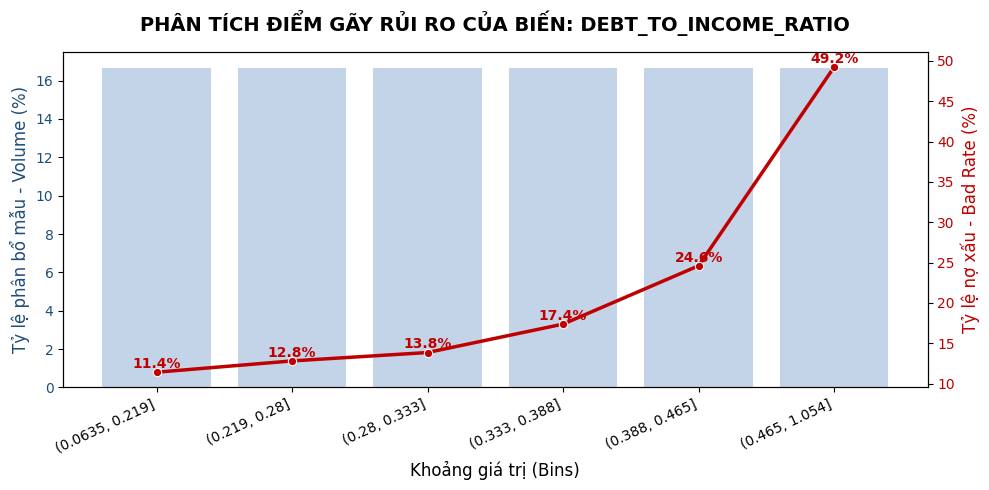

C:\Users\Asus\AppData\Local\Temp\ipykernel_18228\3364164219.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_plot['bin'], rotation=25, ha='right')


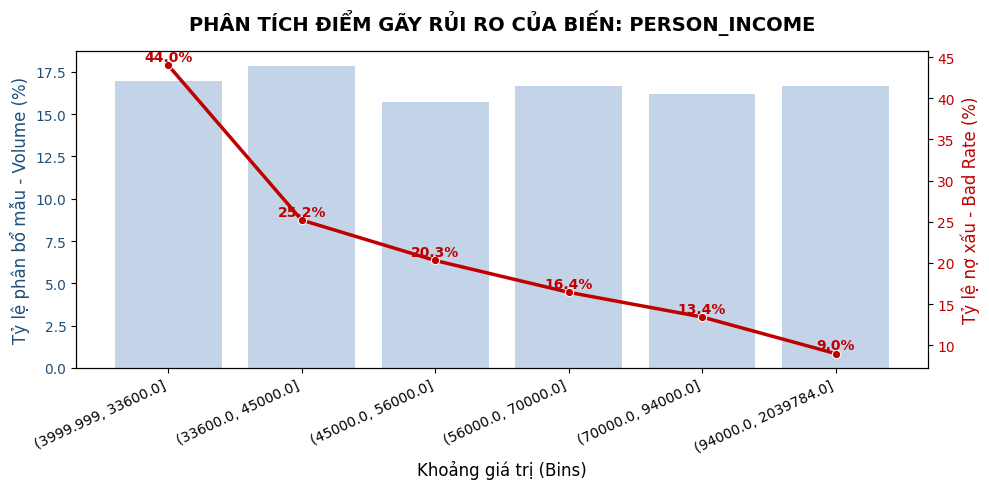

C:\Users\Asus\AppData\Local\Temp\ipykernel_18228\3364164219.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_plot['bin'], rotation=25, ha='right')


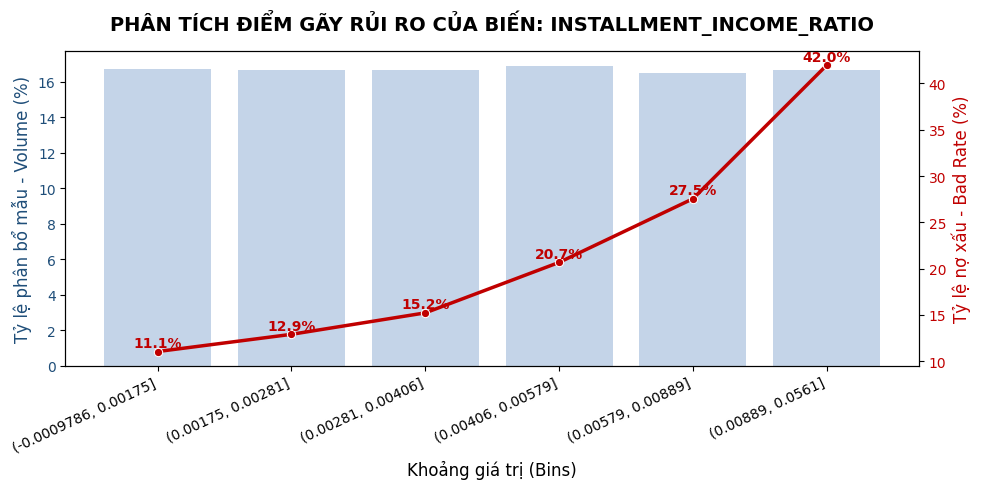

C:\Users\Asus\AppData\Local\Temp\ipykernel_18228\3364164219.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_plot['bin'], rotation=25, ha='right')


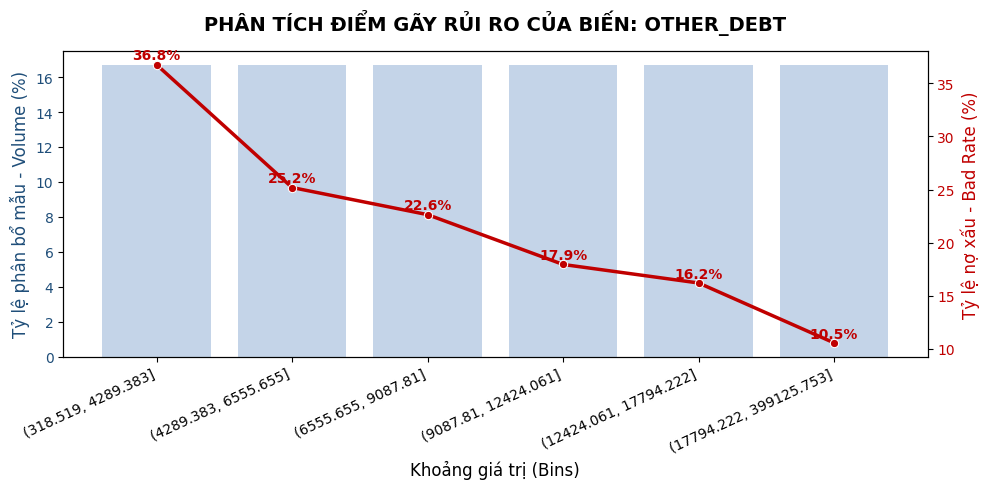

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Danh sách các biến ảnh hưởng lớn nhất cần vẽ
top_features = ['debt_to_income_ratio', 'person_income', 'installment_income_ratio', 'other_debt']

for feat in top_features:
    # 1. Lấy dữ liệu chi tiết của biến từ bảng map WOE
    # Lưu ý: Thay 'woe_maps_new' bằng tên biến dictionary chứa bảng dữ liệu WOE của bạn nếu có khác biệt
    df_plot = woe_maps_new[feat].copy()
    
    # Tính toán tỷ lệ phần trăm phân bổ (Volume %) và Tỷ lệ nợ xấu (Bad Rate %)
    total_samples = df_plot['Total'].sum()
    df_plot['Volume (%)'] = (df_plot['Total'] / total_samples) * 100
    df_plot['Bad_Rate (%)'] = (df_plot['Bad'] / df_plot['Total']) * 100
    
    # Chuyển cột 'bin' thành chuỗi ký tự để làm nhãn cho trục X
    df_plot['bin'] = df_plot['bin'].astype(str)
    
    # 2. Khởi tạo khung bản vẽ hai trục (Dual-axis)
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    # Trục 1: Vẽ Cột (Bar Chart) thể hiện quy mô/phân bổ của nhóm khách hàng (Volume %)
    sns.barplot(x='bin', y='Volume (%)', data=df_plot, ax=ax1, color='#A2C2E8', alpha=0.7)
    ax1.set_title(f'PHÂN TÍCH ĐIỂM GÃY RỦI RO CỦA BIẾN: {feat.upper()}', fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlabel('Khoảng giá trị (Bins)', fontsize=12)
    ax1.set_ylabel('Tỷ lệ phân bổ mẫu - Volume (%)', fontsize=12, color='#1F4E79')
    ax1.tick_params(axis='y', labelcolor='#1F4E79')
    ax1.set_xticklabels(df_plot['bin'], rotation=25, ha='right')
    
    # Trục 2: Tạo trục tung thứ hai bên phải để vẽ Đường (Line Chart) thể hiện tỷ lệ nợ xấu
    ax2 = ax1.twinx()
    sns.lineplot(x='bin', y='Bad_Rate (%)', data=df_plot, ax=ax2, color='#C00000', marker='o', linewidth=2.5, sort=False)
    ax2.set_ylabel('Tỷ lệ nợ xấu - Bad Rate (%)', fontsize=12, color='#C00000')
    ax2.tick_params(axis='y', labelcolor='#C00000')
    
    # Thêm giá trị số (Animate/Text) cụ thể lên đường Bad Rate để dễ quan sát điểm gãy
    for i, val in enumerate(df_plot['Bad_Rate (%)']):
        ax2.text(i, val + 0.5, f'{val:.1f}%', color='#C00000', ha='center', fontweight='bold', fontsize=10)
        
    plt.tight_layout()
    plt.show()